# Optimizing the Piezo Position (Focus-Based)

``` Pseudo
1. Get scanners current position
2. Set resolution (we know range will be 1 um in the xy plane)
3. Build the sequence, centered around the current position
4. For each position in sequence, go to that position and take an image
5. Calculate the focus sharpness for each image, and fit a gaussian distribution to the sequence
6. Plot
```

### Scanner Architecture: GUI to Hardware

- **For positioning**: ScannerGui → ScanningProbeLogic → NiScanningProbeInterfuse → **ni_ao** → Hardware
- **For scanning**: ScannerGui → ScanningProbeLogic → NiScanningProbeInterfuse → **ni_finite_sampling_io** → Hardware
- Interfuse selects appropriate hardware
Piezo stages: x, y, z axes
    - ao0 → x-axis
    - ao1 → y-axis  
    - ao2 → z-axis

## Scanning Optimize Logic Workflow

### on_activate
- Set scan range, resolution, and settings
- Resets all variables
- self._sigNextSequenceStep.connect(self._next_sequence_step, QtCore.Qt.QueuedConnection)
- self._scan_logic().sigScanStateChanged.connect(self._scan_state_changed, QtCore.Qt.QueuedConnection)
- self.sigOptimizeSequenceDimensionsChanged.connect(self._set_default_scan_sequence, QtCore.Qt.QueuedConnection)

### User calls next step and triggers self._start_optimize through the GUI

### start_optimize
- Checks to make sure no other scan/optimization is currently taking place and locks state
- Builds ranges
- Sets self._sequence_index to 0; resets all results
- _next_sequece_step() is called.

### next_sequence_step
- Starts the scan by calling toggle_scan in ScanningProbeLogic class, which calls ScanningProbeLogic.start_scan(scan_axes)

### ScanningProbeLogic.start_scan
- Calls self._scanner().configure_scan(settings), [self._scanner().configure_back_scan(back_settings)], and self._scanner().start_scan()
    - self._scanner = Connector(name='scanner interface=ScanningProbeInterface)
    - Since it connects to ni_scanner, this calls start_scan from 'interfuse.ni_scanning_probe_interfuse.NiScanningProbeInterfuse'
- self.sigScanStateChanged.emit(True, self.scan_data, self.back_scan_data, self._curr_caller_id) -> calls _scan_state_changed

### _scan_state_changed
- Since is_running==True, nothing is returned.

### Scan finishes in hardware
- sigScanStateChanged(False, scan_data, ...)

### _scan_state_changed
- Fits data to 1d/2d gaussian and gets the optimal position for each axis
- Moves piezo to optimal position
- self.sigOptimizeStateChanged.emit(True, position_update, fit_data)
- If all sequences are not finished, calls _next_sequence_step()
- Calls stop_optimize() once all sequences (Z scan, XY scan = 2 sequences) have finished

### next_sequence_step
- Starts the NEXT scan by calling toggle_scan in ScanningProbeLogic class, which calls ScanningProbeLogic.start_scan(scan_axes)

### Repeat above steps for next sequence

## How does ScanningProbeLogic.start_scan(self, scan_axes) work?

1. Checks if module is idle and locks state
2. 

In [12]:
test = dict()
print(test is None)

False


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import cv2
import torch
import torch.nn.functional as F
import time

## SPAD Configuration

In [2]:
spad = camera_SPC3
spad._Nrows = 32
spad._Ncols = 32
spad._apply_camera_settings()

piezo = scanning_probe_logic

laser = dlnsec_laser

## Subtract Background

### Laser States
- OFF = 0
- ON = 1
- LOCKED = 2
- UNKNOWN = 3

In [3]:
def take_bg_image(spad, laser, n_bg_frames=100):
    spad._NFrames = n_bg_frames

    laser.set_laser_state(0) # turn laser off    
    time.sleep(1)  # wait a moment to ensure laser is off


    success = spad.capture_background_image()
    spad.enable_background_subtraction()
    spad._NFrames = 1 

    laser.set_laser_state(1) # turn laser on

    if success == False:
        raise RuntimeError("Failed to capture background image.")
    else:
        print("Background image captured successfully.")
    
    h, w = spad.get_size()
    bg_frame = spad._background_image.reshape(h, w)

    time.sleep(1)  # wait a moment to ensure laser is back on

    return bg_frame # flattened background image

def get_frames(spad, n_frames=1):
    spad._NFrames = n_frames
    frames = spad.start_single_acquisition().squeeze()
    
    frames = np.array(frames).astype('float32')

    if spad._background_subtraction_enabled:
        if not hasattr(spad, "_background_image") or spad._background_image is None:
            raise ValueError("Background subtraction is enabled, but no background image is set.")
        
        h, w = spad.get_size()
        bg_frame = np.array(spad._background_image).reshape(h, w)
        
        frames = frames - bg_frame
        frames = np.clip(frames, 0, None)
    
    return frames

spad.disable_background_subtraction()
laser.set_laser_state(1)
time.sleep(1.5)
before_bg = get_frames(spad, n_frames=1)
bg = take_bg_image(spad, laser, n_bg_frames=5)
h, w = spad.get_size()
bg_frame = bg.reshape(h, w)
print(bg_frame.shape)
after_bg = get_frames(spad, n_frames=1)

Background image captured successfully.
(32, 32)


Background subtraction enabled: True


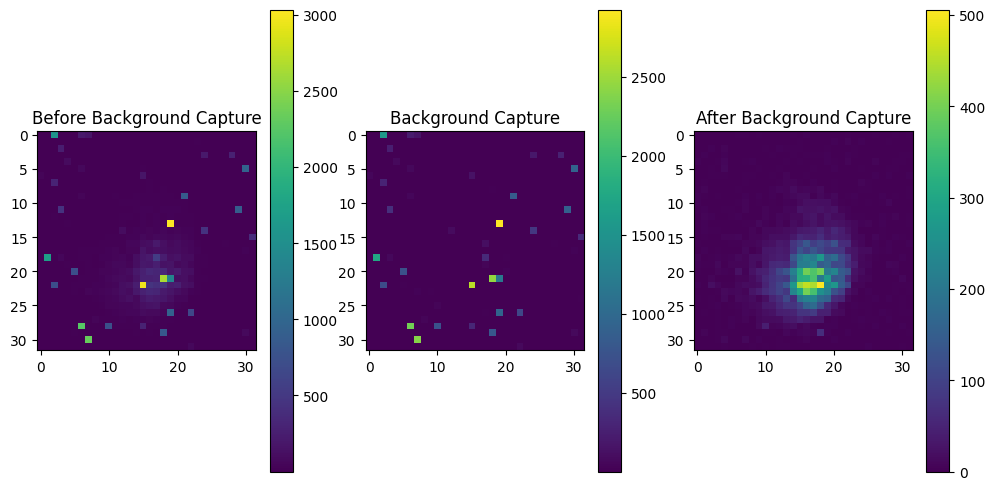

In [4]:
print(f"Background subtraction enabled: {spad._background_subtraction_enabled}")

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title("Before Background Capture")  
plt.imshow(before_bg)
plt.colorbar()
plt.subplot(1,3,2)
plt.title("Background Capture")  
plt.imshow(bg_frame)
plt.colorbar()
plt.subplot(1,3,3)
plt.title("After Background Capture")  
plt.imshow(after_bg)
plt.colorbar()

## Find Centroid and Center Image

Current piezo position: {'x': 0.0001727357, 'y': 1.55863e-05, 'z': 0.0001021522}


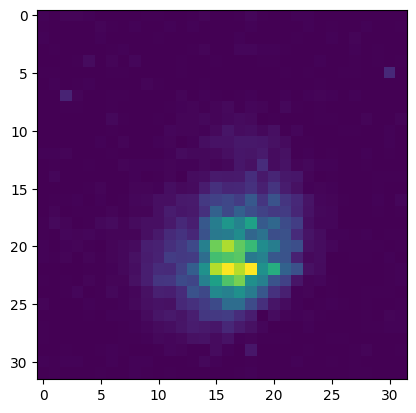

In [5]:
cur_pos = piezo.scanner_position
print("Current piezo position:", cur_pos)
frame = get_frames(spad)
plt.imshow(frame)

Pixel error: (2.0, 4.0) px
Moved piezo by (1.00e-06, 2.00e-06) m


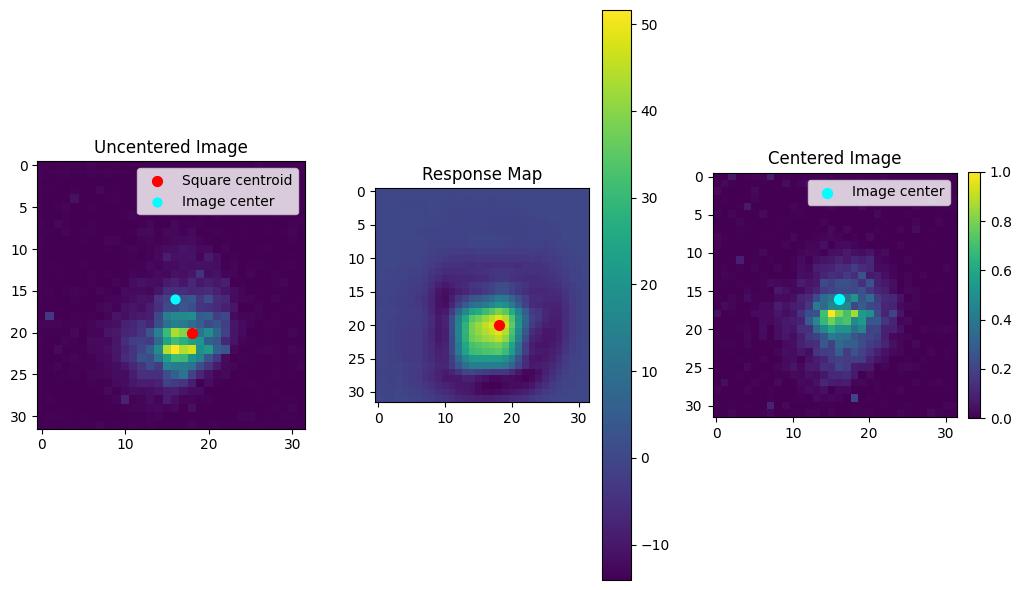

In [6]:
from scipy.signal import correlate2d
import numpy as np

def find_square(image, side):
    """
    Find the centroid of the bright square using a square kernel filter.
    Returns (cx, cy) in pixel coordinates and the response map.
    """
    kernel = np.ones((side, side), dtype=np.float32)
    kernel /= kernel.sum()  # normalize

    response = correlate2d(image.astype(np.float32), kernel, mode='same')

    cy, cx = np.unravel_index(np.argmax(response), response.shape)

    return cx, cy, response


def move_to_square(spad, piezo, nv_dim=5):
    """
    Move piezo so that the detected square (via kernel filtering) is centered.
    Returns response map and detected center.
    """
    image = get_frames(spad)
    h, w = image.shape

    side = nv_dim * 2 - 1
    blur = cv2.blur(image.astype(np.float32), (side, side))
    blur = np.clip(blur, 0, None)
    image -= blur
    cx_px, cy_px, response = find_square(image, side)

    dx_px = cx_px - w // 2
    dy_px = cy_px - h // 2

    dx_m = dx_px / 2.0 * 1e-6
    dy_m = dy_px / 2.0 * 1e-6

    pos = piezo.scanner_position.copy()
    pos["x"] = float(pos["x"]) - float(dx_m)
    pos["y"] = float(pos["y"]) - float(dy_m)
    piezo.set_target_position(pos, move_blocking=True)

    print(f"Pixel error: ({dx_px:.1f}, {dy_px:.1f}) px")
    print(f"Moved piezo by ({dx_m:.2e}, {dy_m:.2e}) m")

    return response, cx_px, cy_px

piezo.set_target_position(cur_pos, move_blocking=True)
time.sleep(1)
frame_uncentered = get_frames(spad)
response, x_center, y_center = move_to_square(spad, piezo, nv_dim=5)
time.sleep(1)
frame_centered = get_frames(spad)
h, w = frame_uncentered.shape

plt.figure(figsize=(10,6))

plt.subplot(1,3,1)
plt.title("Uncentered Image")
plt.imshow(frame_uncentered)
plt.scatter(x_center, y_center, color='red', s=50, label="Square centroid")
plt.scatter(w//2, h//2, color='cyan', s=40, label="Image center")
plt.legend()

plt.subplot(1,3,2)
plt.title("Response Map")
plt.imshow(response)
plt.colorbar()
plt.scatter(x_center, y_center, color='red', s=50)

plt.subplot(1,3,3)
plt.title("Centered Image")
plt.imshow(frame_centered)
plt.scatter(w//2, h//2, color='cyan', s=50, label="Image center")
plt.legend()

plt.tight_layout()

plt.colorbar(ax=plt.gca(), fraction=0.046, pad=0.04)

Pixel error: (0.6, 4.2) px
Moved piezo by (-2.91e-07, -2.12e-06) m


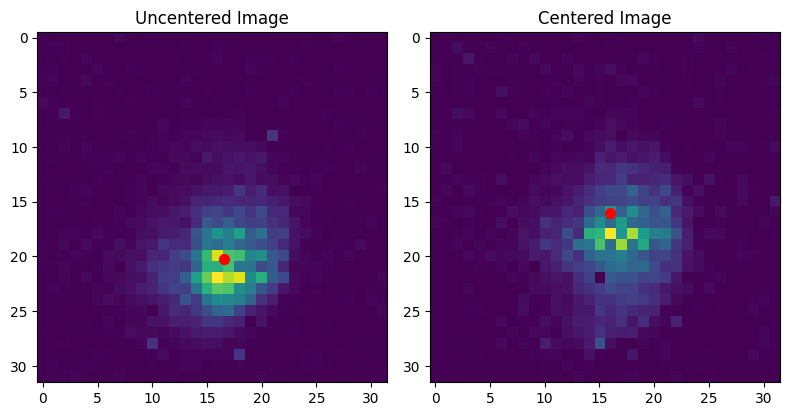

In [7]:
def find_centroid(image):
    M = cv2.moments(image)
    if M["m00"] == 0:
        return image.shape[1] // 2, image.shape[0] // 2
    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]
    return cx, cy

def move_to_centroid(spad, piezo, nv_dim=5):
    image = get_frames(spad)
    h, w = image.shape

    side = nv_dim * 2 - 1
    image_sub = image.astype(np.float32) - cv2.blur(image.astype(np.float32), (side, side))
    image_sub = np.clip(image_sub, 0, None)
    cx_px, cy_px = find_centroid(image_sub)

    dx_px = cx_px - w // 2
    dy_px = cy_px - h // 2

    dx_m = -dx_px / 2.0 * 1e-6
    dy_m = -dy_px / 2.0 * 1e-6

    pos = piezo.scanner_position.copy()
    pos["x"] = float(pos["x"]) + dx_m
    pos["y"] = float(pos["y"]) + dy_m

    piezo.set_target_position(pos, move_blocking=True)

    print(f"Pixel error: ({dx_px:.1f}, {dy_px:.1f}) px")
    print(f"Moved piezo by ({dx_m:.2e}, {dy_m:.2e}) m")

    return cx_px, cy_px


piezo.set_target_position(cur_pos, move_blocking=True)
time.sleep(1)
frame_uncentered = get_frames(spad)
cx, cy = move_to_centroid(spad, piezo)
time.sleep(1)
frame_centered = get_frames(spad)

h, w = frame_uncentered.shape

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Uncentered Image")
plt.imshow(frame_uncentered)
plt.scatter(cx, cy, color='red', s=50)

plt.subplot(1,2,2)
plt.title("Centered Image")
plt.imshow(frame_centered)
plt.scatter(w//2, h//2, color='red', s=50)

plt.tight_layout()

## Building the Sequence

### Optimization Params
- resolution_x = 10 # pixels
- resolution_y = 10 # pixels
- scan_range_x = 1e-6 # units are in m; 1 micron for both x and y ensures pixel is centered on nv
- scan_range_y = 1e-6

In [8]:
resolution_x = 10 # pixels
resolution_y = 10 # pixels
scan_range_x = 1.0e-6 # meters
scan_range_y = 1.0e-6 # meters
arr_dim = 5 # what are the number of nv's in each row and column of the array

x_l_bound, x_u_bound = piezo.scanner_constraints.axes['x'].position.bounds
y_l_bound, y_u_bound = piezo.scanner_constraints.axes['y'].position.bounds

# Build sequence
init_pos = piezo.scanner_position
start_x = init_pos['x'] - scan_range_x / 2
start_y = init_pos['y'] - scan_range_y / 2
sequence_x = np.linspace(start_x, start_x + scan_range_x, int(resolution_x))
sequence_y = np.linspace(start_y, start_y + scan_range_y, int(resolution_y))

# Check params
w, h = spad.get_size()
array_size_microns = 2 * arr_dim - 1 
pxl_per_micron_x = w / array_size_microns  # 32 pixels / 9 microns = 3.56 pxl/micron
pxl_per_micron_y = h / array_size_microns

if sequence_x[0] < x_l_bound or sequence_x[-1] > x_u_bound:
    raise ValueError(f"X scan range [{sequence_x[0]:.2e}, {sequence_x[-1]:.2e}] m exceeds scanner bounds [{x_l_bound:.2e}, {x_u_bound:.2e}] m")

if sequence_y[0] < y_l_bound or sequence_y[-1] > y_u_bound:
    raise ValueError(f"Y scan range [{sequence_y[0]:.2e}, {sequence_y[-1]:.2e}] m exceeds scanner bounds [{y_l_bound:.2e}, {y_u_bound:.2e}] m")

print(init_pos)

{'x': 0.0001724449, 'y': 1.34652e-05, 'z': 0.0001021522}


## Sampling Images in the XY-Plane

### Position Dictionary
```
{'x': 0.0001729267, 'y': 2.8033e-05, 'z': 0.0001018735}
```

In [10]:
crop_dim = 14
img_samples_XY = np.zeros((resolution_x * resolution_y, crop_dim, crop_dim), dtype=np.float32)
img_samples_XY = np.zeros((resolution_x * resolution_y, 32, 32), dtype=np.float32)
pos_dict = {k: float(v) for k, v in init_pos.items()}

idx = 0
for y_sample in sequence_y:
    for x_sample in sequence_x:
        pos_dict['x'] = float(x_sample)
        pos_dict['y'] = float(y_sample)
        
        position = piezo.set_target_position(pos_dict)
        
        frame = get_frames(spad, n_frames=1)
        # cropped = frame[9:23, 9:23]
        frame_cropped = frame
        img_samples_XY[idx] = frame_cropped.astype(np.float32)
        idx += 1
        print(f"Captured frame {idx}/{resolution_x * resolution_y}")

print(f"Final shape: {img_samples_XY.shape}")

Captured frame 1/100
Captured frame 2/100
Captured frame 3/100
Captured frame 4/100
Captured frame 5/100
Captured frame 6/100
Captured frame 7/100
Captured frame 8/100
Captured frame 9/100
Captured frame 10/100
Captured frame 11/100
Captured frame 12/100
Captured frame 13/100
Captured frame 14/100
Captured frame 15/100
Captured frame 16/100
Captured frame 17/100
Captured frame 18/100
Captured frame 19/100
Captured frame 20/100
Captured frame 21/100
Captured frame 22/100
Captured frame 23/100
Captured frame 24/100
Captured frame 25/100
Captured frame 26/100
Captured frame 27/100
Captured frame 28/100
Captured frame 29/100
Captured frame 30/100
Captured frame 31/100
Captured frame 32/100
Captured frame 33/100
Captured frame 34/100
Captured frame 35/100
Captured frame 36/100
Captured frame 37/100
Captured frame 38/100
Captured frame 39/100
Captured frame 40/100
Captured frame 41/100
Captured frame 42/100
Captured frame 43/100
Captured frame 44/100
Captured frame 45/100
Captured frame 46/1

## Calculating Optimal Position Using Sharpness and Focus Metrics

### Finding Position of Best Focus

In [ ]:
def sharpness_checkerboard(imgs, method="contrast", nv_dim=None):
    """
    Compute sharpness metrics only on the central region of each image.
    
    Parameters:
        imgs : list or array of 2D images
        method : "contrast" or "fft"
        nv_dim : integer, defines the size of the central patch as (nv_dim*2 - 1)
    """
    sharpness = []
    brightness = []

    for img in imgs:
        img = img.astype(np.float32)
        brightness.append(np.sum(img))  # full-image brightness

        # normalize for focus metric
        img = img / (img.mean() + 1e-6)

        # Crop central region if nv_dim is given
        if nv_dim is not None:
            H, W = img.shape
            patch_size = nv_dim * 2 - 1
            h_center = H // 2
            w_center = W // 2
            h_start = max(h_center - patch_size // 2, 0)
            h_end   = min(h_center + patch_size // 2 + 1, H)
            w_start = max(w_center - patch_size // 2, 0)
            w_end   = min(w_center + patch_size // 2 + 1, W)
            img_patch = img[h_start:h_end, w_start:w_end]
        else:
            img_patch = img

        # Compute sharpness
        if method == "contrast":
            dx = img_patch[:, 1:] - img_patch[:, :-1]
            dy = img_patch[1:, :] - img_patch[:-1, :]
            s = np.mean(dx*dx) + np.mean(dy*dy)
        elif method == "fft":
            F = np.fft.fftshift(np.fft.fft2(img_patch))
            power = np.abs(F)**2
            s = power[0,0] + power[0,-1] + power[-1,0] + power[-1,-1]
        else:
            raise ValueError("Unknown method")

        sharpness.append(s)

    return np.array(sharpness), np.array(brightness)

def sharpness_global(imgs):
    sharpness = []
    brightness = []
    for img in imgs:
        img = img.astype(np.float32)
        brightness.append(np.sum(img))
        img = img / (img.mean() + 1e-6)
        img = cv2.GaussianBlur(img, (3,3), 0)
        lap = cv2.Laplacian(img, cv2.CV_32F)
        sharpness.append(np.var(lap))

    return np.array(sharpness), np.array(brightness)

# Calculate focus metrics
focus_contrast, brightness_contrast = sharpness_checkerboard(img_samples_XY, method="contrast")
focus_fft, brightness_fft = sharpness_checkerboard(img_samples_XY, method="fft")
focus_global, brightness_global = sharpness_global(img_samples_XY)

# Find max indices
idx_contrast_focus = np.argmax(focus_contrast)
cx, cy = np.unravel_index(idx_contrast_focus, (resolution_x, resolution_y))
idx_fft_focus = np.argmax(focus_fft)
fx, fy = np.unravel_index(idx_fft_focus, (resolution_x, resolution_y))
idx_global_focus = np.argmax(focus_global)
gx, gy = np.unravel_index(idx_global_focus, (resolution_x, resolution_y))

idx_contrast_bright = np.argmax(brightness_contrast)
cbx, cby = np.unravel_index(idx_contrast_bright, (resolution_x, resolution_y))
idx_fft_bright = np.argmax(brightness_fft)
fbx, fby = np.unravel_index(idx_fft_bright, (resolution_x, resolution_y))
idx_global_bright = np.argmax(brightness_global)
gbx, gby = np.unravel_index(idx_global_bright, (resolution_x, resolution_y))

# Physical coordinates
contrast_focus_pos = (sequence_x[cx], sequence_y[cy])
fft_focus_pos = (sequence_x[fx], sequence_y[fy])
global_focus_pos = (sequence_x[gx], sequence_y[gy])

contrast_bright_pos = (sequence_x[cbx], sequence_y[cby])
fft_bright_pos = (sequence_x[fbx], sequence_y[fby])
global_bright_pos = (sequence_x[gbx], sequence_y[gby])

# Print results
print("=== Focus Metric (XY scan) ===")
print(f"Contrast-based: Max focus = {focus_contrast[idx_contrast_focus]*1e6:.6f}, "
      f"Index = ({cx}, {cy}), Position = ({contrast_focus_pos[0]*1e6:.6f}, {contrast_focus_pos[1]*1e6:.6f}) microns")
print(f"FFT-based:      Max focus = {focus_fft[idx_fft_focus]*1e6:.6f}, "
      f"Index = ({fx}, {fy}), Position = ({fft_focus_pos[0]*1e6:.6f}, {fft_focus_pos[1]*1e6:.6f}) microns")
print(f"Global-based:   Max focus = {focus_global[idx_global_focus]*1e6:.6f}, "
      f"Index = ({gx}, {gy}), Position = ({global_focus_pos[0]*1e6:.6f}, {global_focus_pos[1]*1e6:.6f}) microns")
print("\n=== Brightness Metric (XY scan) ===")
print(f"Contrast-based brightness peak @ ({contrast_bright_pos[0]*1e6:.6f}, {contrast_bright_pos[1]*1e6:.6f}) microns")
print(f"FFT-based brightness peak @ ({fft_bright_pos[0]*1e6:.6f}, {fft_bright_pos[1]*1e6:.6f}) microns")
print(f"Global-based brightness peak @ ({global_bright_pos[0]*1e6:.6f}, {global_bright_pos[1]*1e6:.6f}) microns")

=== Focus Metric (XY scan) ===
Contrast-based: Max focus = 1871155.738831, Index = (6, 7), Position = (172.577367, 18.457978) microns
FFT-based:      Max focus = 2060432839.175252, Index = (1, 1), Position = (172.021811, 17.791311) microns
Global-based:   Max focus = 226395.055652, Index = (9, 7), Position = (172.910700, 18.457978) microns

=== Brightness Metric (XY scan) ===
Contrast-based brightness peak @ (171.910700, 17.791311) microns
FFT-based brightness peak @ (171.910700, 17.791311) microns
Global-based brightness peak @ (171.910700, 17.791311) microns


In [ ]:
# img_samples = np.nan_to_num(img_samples, 0)

# def sum_array_batched(imgs, pxl_per_micron_x, pxl_per_micron_y):
#     """Apply kernel convolution to extract NV features at grid positions."""
#     imgs = torch.from_numpy(imgs).float().unsqueeze(1)

#     nv_size_x = int(pxl_per_micron_x)  # pixels per NV
#     nv_size_y = int(pxl_per_micron_y)

#     # Kernel stride
#     spacing_x = int(2 * pxl_per_micron_x)  
#     spacing_y = int(2 * pxl_per_micron_y)
#     stride = (spacing_y, spacing_x)

#     # Kernel = 1 micron NV box
#     kernel = torch.ones((1, 1, nv_size_y, nv_size_x), dtype=imgs.dtype)

#     out = F.conv2d(imgs, kernel, stride=stride, padding=0)
#     brightness = out.squeeze(1).cpu().numpy()
#     return brightness

# def laplacian_variance_grid(imgs, roi_fraction=0.8):
#     """
#     Uses region of interest (ROI) to focus on center and larger kernel for better grid edge detection.
    
#     Args:
#         imgs: Array of images (N, H, W)
#         roi_fraction: Fraction of image to use (0.8 = use center 80%)
#     """
#     sharpness = np.zeros(imgs.shape[0])
#     h, w = imgs.shape[1], imgs.shape[2]
    
#     roi_h = int(h * roi_fraction)
#     roi_w = int(w * roi_fraction)
#     y_start = (h - roi_h) // 2
#     x_start = (w - roi_w) // 2
    
#     for i in range(imgs.shape[0]):
#         roi = imgs[i, y_start:y_start+roi_h, x_start:x_start+roi_w]
        
#         img_uint8 = np.clip(roi, 0, 255).astype(np.uint8)
        
#         laplacian = cv2.Laplacian(img_uint8, cv2.CV_64F, ksize=5)
        
#         sharpness[i] = laplacian.var()
    
#     return sharpness

# def kernel_based_focus(imgs, pxl_per_micron_x, pxl_per_micron_y):
#     """
#     Focus metric based on NV grid kernel convolution.
#     More accurate for grid patterns - focuses on actual NV positions.
    
#     Args:
#         imgs: Array of images (N, H, W)
#         pxl_per_micron_x, pxl_per_micron_y: Kernel size parameters
    
#     Returns:
#         Sharpness metric for each image
#     """
#     nv_features = sum_array_batched(imgs, pxl_per_micron_x, pxl_per_micron_y)
    
#     sharpness = np.var(nv_features, axis=(1, 2))
    
#     return sharpness

# # Calculate focus metrics using BOTH methods for comparison
# focus_kernel = kernel_based_focus(img_samples, pxl_per_micron_x, pxl_per_micron_y)
# focus_laplacian_grid = laplacian_variance_grid(img_samples, roi_fraction=0.8)

# print(f"Original: {img_samples.shape}")
# print(f"Kernel focus range: [{focus_kernel.min():.2f}, {focus_kernel.max():.2f}]")
# print(f"Laplacian focus range: [{focus_laplacian_grid.min():.2f}, {focus_laplacian_grid.max():.2f}]")

## Compare Focus Methods

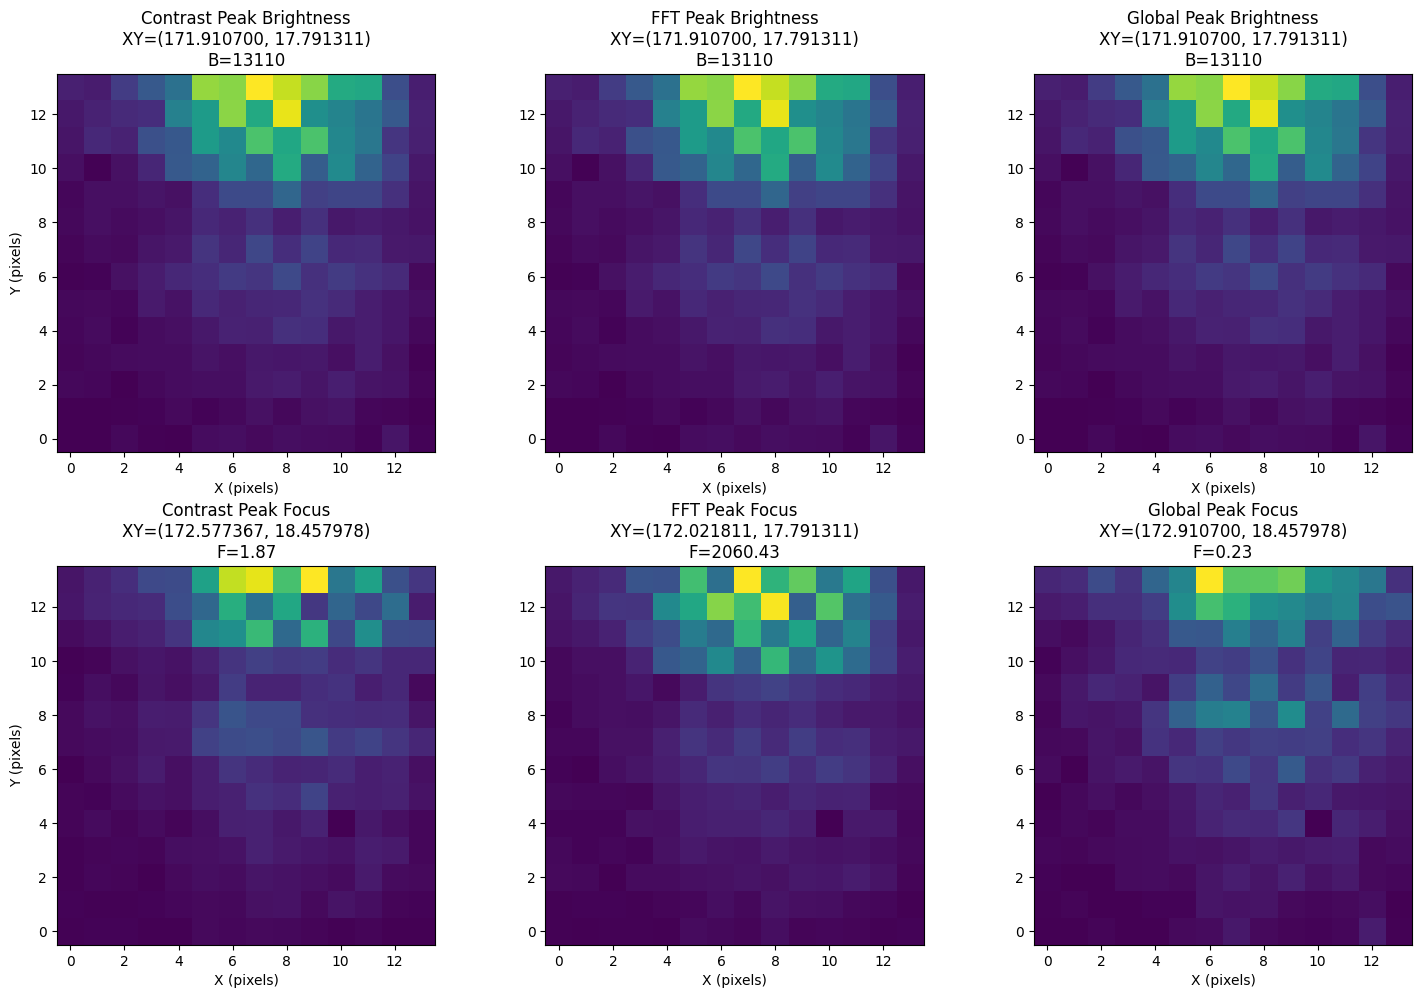


=== Peak Brightness Positions ===
Contrast: XY=(171.910700, 17.791311)
FFT:      XY=(171.910700, 17.791311)
Global:   XY=(171.910700, 17.791311)

=== Peak Focus Positions ===
Contrast: XY=(172.577367, 18.457978)
FFT:      XY=(172.021811, 17.791311)
Global:   XY=(172.910700, 18.457978)

=== Brightness vs Focus Agreement ===
Contrast: |Δ| = 66 frames
FFT:      |Δ| = 10 frames
Global:   |Δ| = 96 frames


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Map indices to XY positions
def idx_to_xy(idx, X, Y):
    return divmod(idx, Y)  # returns (x_idx, y_idx)

# Peak images
img_contrast_bright = img_samples_XY[idx_contrast_bright]
img_fft_bright      = img_samples_XY[idx_fft_bright]
img_global_bright   = img_samples_XY[idx_global_bright]

img_contrast_focus  = img_samples_XY[idx_contrast_focus]
img_fft_focus       = img_samples_XY[idx_fft_focus]
img_global_focus    = img_samples_XY[idx_global_focus]

# --------------------
# Peak Brightness Row
# --------------------
axes[0, 0].imshow(img_contrast_bright, origin="lower")
cx, cy = idx_to_xy(idx_contrast_bright, resolution_x, resolution_y)
axes[0, 0].set_title(
    f"Contrast Peak Brightness\n"
    f"XY=({sequence_x[cx]*1e6:.6f}, {sequence_y[cy]*1e6:.6f})\n"
    f"B={brightness_contrast[idx_contrast_bright]:.0f}"
)
axes[0, 0].set_ylabel("Y (pixels)")

axes[0, 1].imshow(img_fft_bright, origin="lower")
fx, fy = idx_to_xy(idx_fft_bright, resolution_x, resolution_y)
axes[0, 1].set_title(
    f"FFT Peak Brightness\n"
    f"XY=({sequence_x[fx]*1e6:.6f}, {sequence_y[fy]*1e6:.6f})\n"
    f"B={brightness_fft[idx_fft_bright]:.0f}"
)

axes[0, 2].imshow(img_global_bright, origin="lower")
gx, gy = idx_to_xy(idx_global_bright, resolution_x, resolution_y)
axes[0, 2].set_title(
    f"Global Peak Brightness\n"
    f"XY=({sequence_x[gx]*1e6:.6f}, {sequence_y[gy]*1e6:.6f})\n"
    f"B={brightness_global[idx_global_bright]:.0f}"
)

# ----------------
# Peak Focus Row
# ----------------
axes[1, 0].imshow(img_contrast_focus, origin="lower")
cx_f, cy_f = idx_to_xy(idx_contrast_focus, resolution_x, resolution_y)
axes[1, 0].set_title(
    f"Contrast Peak Focus\n"
    f"XY=({sequence_x[cx_f]*1e6:.6f}, {sequence_y[cy_f]*1e6:.6f})\n"
    f"F={focus_contrast[idx_contrast_focus]:.2f}"
)
axes[1, 0].set_ylabel("Y (pixels)")

axes[1, 1].imshow(img_fft_focus, origin="lower")
fx_f, fy_f = idx_to_xy(idx_fft_focus, resolution_x, resolution_y)
axes[1, 1].set_title(
    f"FFT Peak Focus\n"
    f"XY=({sequence_x[fx_f]*1e6:.6f}, {sequence_y[fy_f]*1e6:.6f})\n"
    f"F={focus_fft[idx_fft_focus]:.2f}"
)

axes[1, 2].imshow(img_global_focus, origin="lower")
gx_f, gy_f = idx_to_xy(idx_global_focus, resolution_x, resolution_y)
axes[1, 2].set_title(
    f"Global Peak Focus\n"
    f"XY=({sequence_x[gx_f]*1e6:.6f}, {sequence_y[gy_f]*1e6:.6f})\n"
    f"F={focus_global[idx_global_focus]:.2f}"
)

for ax in axes.flat:
    ax.set_xlabel("X (pixels)")

plt.tight_layout()
plt.show()

# --------------------
# Print summary
# --------------------
print("\n=== Peak Brightness Positions ===")
print(f"Contrast: XY=({sequence_x[cx]*1e6:.6f}, {sequence_y[cy]*1e6:.6f})")
print(f"FFT:      XY=({sequence_x[fx]*1e6:.6f}, {sequence_y[fy]*1e6:.6f})")
print(f"Global:   XY=({sequence_x[gx]*1e6:.6f}, {sequence_y[gy]*1e6:.6f})")

print("\n=== Peak Focus Positions ===")
print(f"Contrast: XY=({sequence_x[cx_f]*1e6:.6f}, {sequence_y[cy_f]*1e6:.6f})")
print(f"FFT:      XY=({sequence_x[fx_f]*1e6:.6f}, {sequence_y[fy_f]*1e6:.6f})")
print(f"Global:   XY=({sequence_x[gx_f]*1e6:.6f}, {sequence_y[gy_f]*1e6:.6f})")

print("\n=== Brightness vs Focus Agreement ===")
print(f"Contrast: |Δ| = {abs(idx_contrast_bright - idx_contrast_focus)} frames")
print(f"FFT:      |Δ| = {abs(idx_fft_bright - idx_fft_focus)} frames")
print(f"Global:   |Δ| = {abs(idx_global_bright - idx_global_focus)} frames")


In [ ]:
focus_metric= focus_contrast
focus_metric = focus_metric.reshape((resolution_x, resolution_y))

## Fit 2D Gaussian to Focus Data

In [ ]:
def gaussian_2d(XY, amplitude, x_center, y_center, sigma_x, sigma_y, background):
    x, y = XY
    g = background + amplitude * np.exp(
        -(((x - x_center) ** 2) / (2 * sigma_x ** 2) +
          ((y - y_center) ** 2) / (2 * sigma_y ** 2))
    )
    return g.ravel()

X, Y = np.meshgrid(sequence_x, sequence_y, indexing="xy")
z = focus_metric.astype(float)

row_max, col_max = np.unravel_index(np.argmax(z), z.shape)
x_center_guess = X[row_max, col_max]
y_center_guess = Y[row_max, col_max]
background_guess = float(np.min(z))
amplitude_guess = float(z[row_max, col_max] - background_guess)

scan_range_x_local = float(sequence_x.max() - sequence_x.min())
scan_range_y_local = float(sequence_y.max() - sequence_y.min())
sigma_x_guess = scan_range_x_local / 4.0 if scan_range_x_local > 0 else 1.0
sigma_y_guess = scan_range_y_local / 4.0 if scan_range_y_local > 0 else 1.0

p0 = (amplitude_guess, x_center_guess, y_center_guess, sigma_x_guess, sigma_y_guess, background_guess)

bounds = (
    [0.0, sequence_x.min(), sequence_y.min(), 1e-12, 1e-12, -np.inf],
    [np.inf, sequence_x.max(), sequence_y.max(), np.inf, np.inf,  np.inf],
)

popt, _ = curve_fit(
    gaussian_2d,
    (X, Y),
    z.ravel(),
    p0=p0,
    bounds=bounds
)

amplitude_fit, x_center_fit, y_center_fit, sigma_x_fit, sigma_y_fit, background_fit = popt

pred = (background_fit + amplitude_fit * np.exp(
    -(((X - x_center_fit) ** 2) / (2 * sigma_x_fit ** 2) +
      ((Y - y_center_fit) ** 2) / (2 * sigma_y_fit ** 2))
))

resid = z - pred

sse = float(np.sum(resid**2))
sst = float(np.sum((z - np.mean(z))**2))
r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")
rmse = float(np.sqrt(np.mean(resid**2)))

print("Peak location:", x_center_fit, y_center_fit)
print("amplitude, background:", amplitude_fit, background_fit)
print("sigma_x, sigma_y:", sigma_x_fit, sigma_y_fit)
print(f"R-Squared: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

# Move to fitted optimal position and capture
pos_dict["x"], pos_dict["y"] = float(x_center_fit), float(y_center_fit)
position = piezo.set_target_position(pos_dict, move_blocking=True)
time.sleep(1)

frames = get_frames(spad, n_frames=5)
frame_avg = np.mean(frames, axis=0)

plt.figure(figsize=(8, 6))
plt.imshow(np.flipud(frame_avg), origin='lower')
plt.colorbar(label='Counts')
plt.title(f'Gaussian Fit Position: ({x_center_fit*1e6:.3f}, {y_center_fit*1e6:.3f}) µm\n(avg of 5 frames)')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.show()

Peak location: 0.0001724720420119465 1.8378344798957072e-05
amplitude, background: 0.556429276501379 0.9262510100588329
sigma_x, sigma_y: 4.1550462407355886e-07 6.806618701284135e-08
R-Squared: 0.216
RMSE: 0.244


AttributeError: 'NoneType' object has no attribute 'squeeze'

In [ ]:
spad._NFrames = 5

print(spad.start_single_acquisition())

None


## Plot Gaussian Fit Quality

In [ ]:
plt.figure(figsize=(12, 4))

vmin = min(z.min(), pred.min())
vmax = max(z.max(), pred.max())

plt.subplot(1, 3, 1)
plt.title("Measured Focus")
plt.imshow(z, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 2)
plt.title("Predicted (Gaussian fit)")
plt.imshow(pred, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 3)
plt.title("Residual (meas - pred)")
m = np.max(np.abs(resid))
plt.imshow(resid, origin="lower", vmin=-m, vmax=m, cmap='RdBu')
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()